# Resource Analysis: Computational Cost and Efficiency

This notebook analyzes the computational costs of MCMC vs SBI, demonstrating the efficiency gains of amortized inference.

In [5]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..") / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

from hx_models.style import (
    apply_paper_style, SCENARIO_COLORS, SCENARIO_LABELS_SHORT,
    MCMC_COLOR, SBI_COLOR, TRUE_COLOR, PARAM_LABELS, save_fig,
)

apply_paper_style()

figures_dir = Path("../figures")
figures_dir.mkdir(parents=True, exist_ok=True)
results_dir = Path("../results")

## Load Timing and Accuracy Data

In [ ]:
import json as _json

metrics_path = results_dir / "metrics_summary.json"
sbi_path = results_dir / "sbi_posteriors.npz"
mcmc_path = results_dir / "mcmc_posteriors.npz"

assert metrics_path.exists(), (
    f"{metrics_path} not found. Run notebook 04 through the metrics cell "
    "to write metrics_summary.json."
)
assert sbi_path.exists(), (
    f"{sbi_path} not found. Run notebook 04 to train/cache SBI results."
)
assert mcmc_path.exists(), (
    f"{mcmc_path} not found. Run notebook 04 to cache MCMC results."
)

SCENARIO_NAMES = [
    "scenario_1_normal_operation",
    "scenario_2_batch_shutdown",
    "scenario_3_boiler_feedwater",
    "scenario_4_mild_tube_leak",
    "scenario_5_severe_tube_leak",
    "scenario_6_no_failure",
]

with open(metrics_path) as f:
    metrics_summary = _json.load(f)

for s in SCENARIO_NAMES:
    assert s in metrics_summary, f"Scenario {s} missing from {metrics_path}"

mcmc_time_per_obs = {s: metrics_summary[s]["mcmc_time_per_obs"] for s in SCENARIO_NAMES}
sbi_time_per_obs = {s: metrics_summary[s]["sbi_time_per_obs"] for s in SCENARIO_NAMES}
mcmc_crps_tau = {s: metrics_summary[s]["mcmc_crps_tau"] for s in SCENARIO_NAMES}
sbi_crps_tau = {s: metrics_summary[s]["sbi_crps_tau"] for s in SCENARIO_NAMES}
mcmc_classification_acc = {s: metrics_summary[s]["mcmc_classification_acc"] for s in SCENARIO_NAMES}
sbi_classification_acc = {s: metrics_summary[s]["sbi_classification_acc"] for s in SCENARIO_NAMES}

sbi_data = np.load(sbi_path)
_tt = sbi_data.get("training_time", np.array([0.0]))
sbi_training_time = float(np.asarray(_tt).ravel()[0])


N_SBI_SIMS = 50_000
TARGET_ACC = 0.95
avg_sbi_mode_acc = float(np.mean(list(sbi_classification_acc.values())))


MCMC_NUM_CHAINS = 4
MCMC_NUM_WARMUP = 1500
MCMC_NUM_SAMPLES = 2500
MCMC_POSTERIOR_DRAWS_PER_INFERENCE = MCMC_NUM_CHAINS * MCMC_NUM_SAMPLES
MCMC_TOTAL_TRANSITIONS_PER_INFERENCE = MCMC_NUM_CHAINS * (MCMC_NUM_WARMUP + MCMC_NUM_SAMPLES)


mcmc_data = np.load(mcmc_path)
mcmc_tau_keys = [k for k in mcmc_data.files if k.endswith("__tau_samples")]
assert len(mcmc_tau_keys) > 0, "Could not find mcmc tau sample arrays in mcmc_posteriors.npz"
cached_draws = int(mcmc_data[mcmc_tau_keys[0]].shape[1])
if cached_draws != MCMC_POSTERIOR_DRAWS_PER_INFERENCE:
    print(
        f"Warning: cached posterior draws ({cached_draws}) != configured draws "
        f"({MCMC_POSTERIOR_DRAWS_PER_INFERENCE}). Using configured value."
    )

print(f"Loaded metrics from {metrics_path}")
print("Timing summary:")
for i, s in enumerate(SCENARIO_NAMES):
    speedup = mcmc_time_per_obs[s] / max(sbi_time_per_obs[s], 1e-6)
    print(f"  {SCENARIO_LABELS_SHORT[i]}: MCMC={mcmc_time_per_obs[s]:.1f}s, "
          f"SBI={sbi_time_per_obs[s]:.3f}s, Speedup={speedup:.0f}x")

print(f"SBI training simulations: {N_SBI_SIMS:,}")
print(
    f"MCMC per-inference: {MCMC_NUM_CHAINS} chains, "
    f"{MCMC_NUM_WARMUP} warmup, {MCMC_NUM_SAMPLES} posterior samples"
)
print(f"Average SBI mode accuracy: {avg_sbi_mode_acc*100:.1f}%")

Loaded metrics from ../results/metrics_summary.json
Timing summary:
  Normal Op.: MCMC=171.9s, SBI=0.116s, Speedup=1481x
  Batch SD: MCMC=167.1s, SBI=0.119s, Speedup=1409x
  Boiler FW: MCMC=146.1s, SBI=0.120s, Speedup=1215x
  Mild Leak: MCMC=144.9s, SBI=0.125s, Speedup=1160x
  Severe Leak: MCMC=139.1s, SBI=0.118s, Speedup=1175x
  No Failure: MCMC=37.0s, SBI=0.129s, Speedup=288x
SBI training simulations: 50,000
MCMC per-inference: 4 chains, 1500 warmup, 2500 posterior samples
Average SBI mode accuracy: 99.5%


## 1. Amortization Break-Even Plot

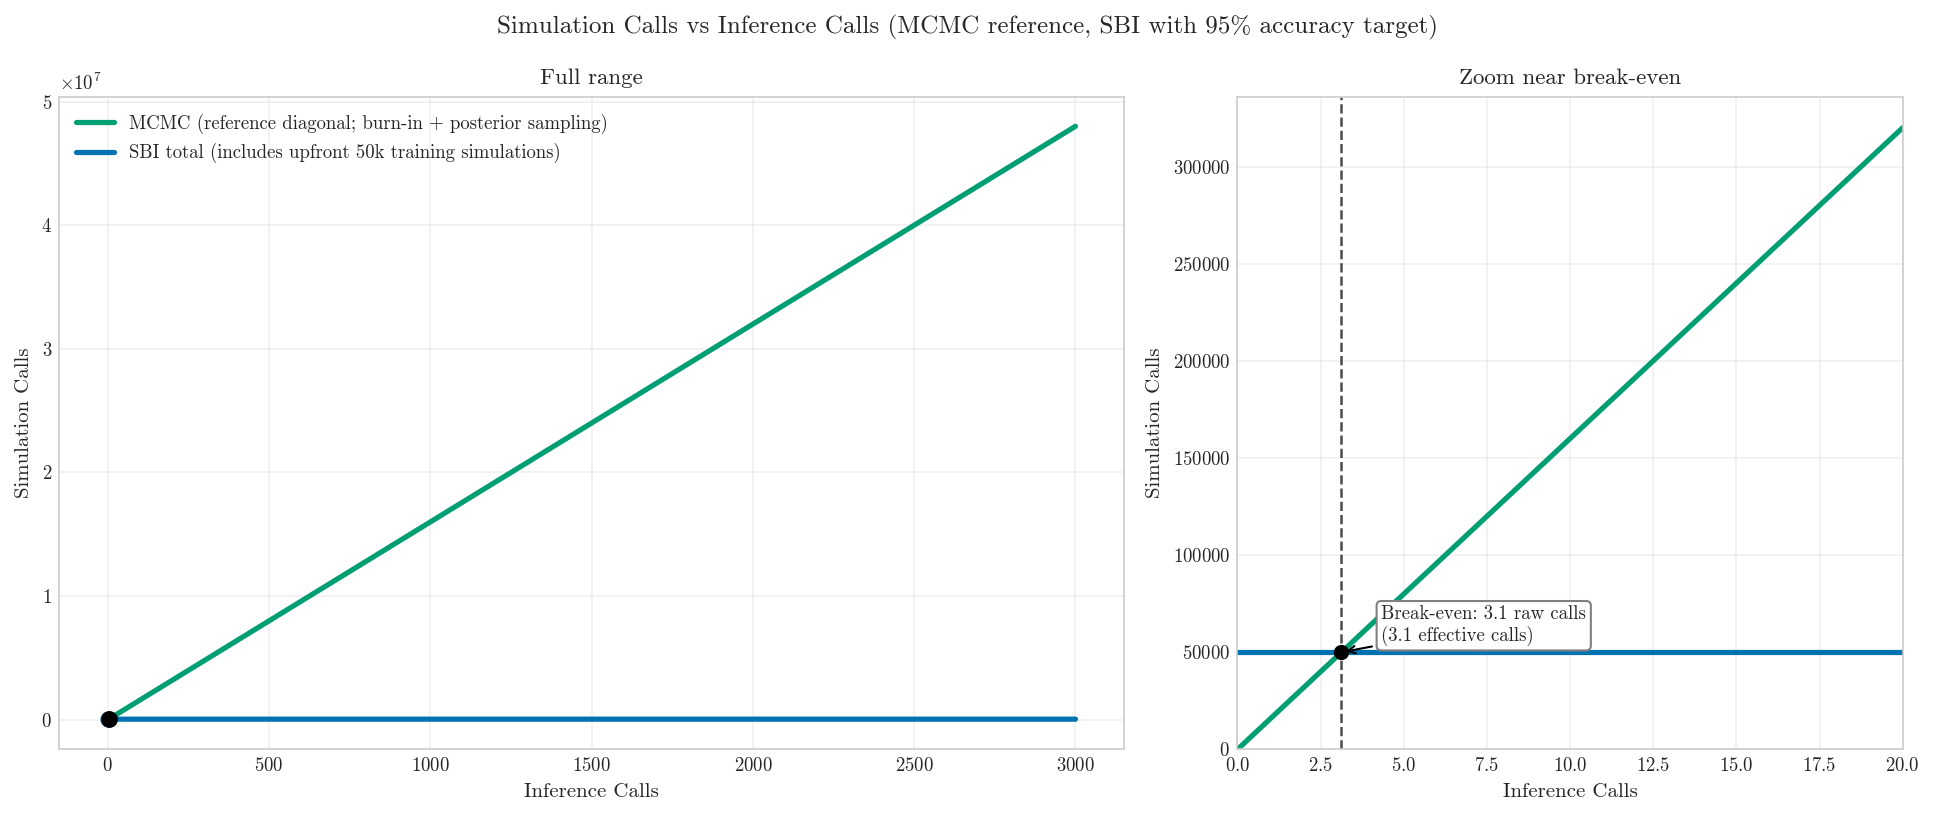

In [24]:
n_calls_raw = np.arange(0, 3001)

accuracy_factor = min(avg_sbi_mode_acc / TARGET_ACC, 1.0)
accuracy_factor = max(accuracy_factor, 1e-12)


sbi_effective_calls = n_calls_raw * accuracy_factor
mcmc_sim_calls = MCMC_TOTAL_TRANSITIONS_PER_INFERENCE * n_calls_raw
sbi_sim_calls = np.full_like(n_calls_raw, N_SBI_SIMS, dtype=float)

breakeven_effective_calls = N_SBI_SIMS / max(MCMC_TOTAL_TRANSITIONS_PER_INFERENCE, 1e-12)
breakeven_raw_calls = breakeven_effective_calls / accuracy_factor

fig, (ax, ax_zoom) = plt.subplots(
    1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios': [1.6, 1.0]}
)

# Main view: full horizon (shows long-run amortization clearly).
ax.plot(
    n_calls_raw,
    mcmc_sim_calls,
    color=MCMC_COLOR,
    lw=2.5,
    label='MCMC (reference diagonal; burn-in + posterior sampling)'
)
ax.plot(
    n_calls_raw,
    sbi_sim_calls,
    color=SBI_COLOR,
    lw=2.5,
    label='SBI total (includes upfront 50k training simulations)'
)

ax.scatter([0], [N_SBI_SIMS], color=SBI_COLOR, s=45, zorder=5)

ax.scatter([breakeven_raw_calls], [N_SBI_SIMS], color='black', s=50, zorder=5)

ax.set_xlabel('Inference Calls')
ax.set_ylabel('Simulation Calls')
ax.set_title('Full range')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper left')


zoom_max_calls = 20
x_zoom = np.arange(0, zoom_max_calls + 1)
ax_zoom.plot(x_zoom, MCMC_TOTAL_TRANSITIONS_PER_INFERENCE * x_zoom, color=MCMC_COLOR, lw=2.5)
ax_zoom.plot(x_zoom, np.full_like(x_zoom, N_SBI_SIMS), color=SBI_COLOR, lw=2.5)
ax_zoom.scatter([breakeven_raw_calls], [N_SBI_SIMS], color='black', s=40, zorder=5)
ax_zoom.axvline(breakeven_raw_calls, color='black', ls='--', lw=1.2, alpha=0.7)
ax_zoom.annotate(
    f'Break-even: {breakeven_raw_calls:.1f} raw calls\n({breakeven_effective_calls:.1f} effective calls)',
    xy=(breakeven_raw_calls, N_SBI_SIMS),
    xytext=(breakeven_raw_calls + 1.2, N_SBI_SIMS * 1.12),
    fontsize=9,
    arrowprops=dict(arrowstyle='->', color='black'),
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='gray')
)
ax_zoom.set_xlim(0, zoom_max_calls)
ax_zoom.set_ylim(0, max(N_SBI_SIMS * 1.25, MCMC_TOTAL_TRANSITIONS_PER_INFERENCE * zoom_max_calls * 1.05))
ax_zoom.set_xlabel('Inference Calls')
ax_zoom.set_ylabel('Simulation Calls')
ax_zoom.set_title('Zoom near break-even')
ax_zoom.grid(True, alpha=0.3)

fig.suptitle('Simulation Calls vs Inference Calls (MCMC reference, SBI with 95% accuracy target)')

plt.tight_layout()
save_fig(fig, figures_dir / "sim_calls_vs_inference_calls")
plt.show()

## 2. Radar Chart

Radar chart (each axis: 1.0 = best of the two methods on that metric):
  $\tau$ (CRPS): MCMC=1.000, SBI=0.729
  Mode Classification: MCMC=0.999, SBI=1.000
  Inference Speed: MCMC=0.001, SBI=1.000


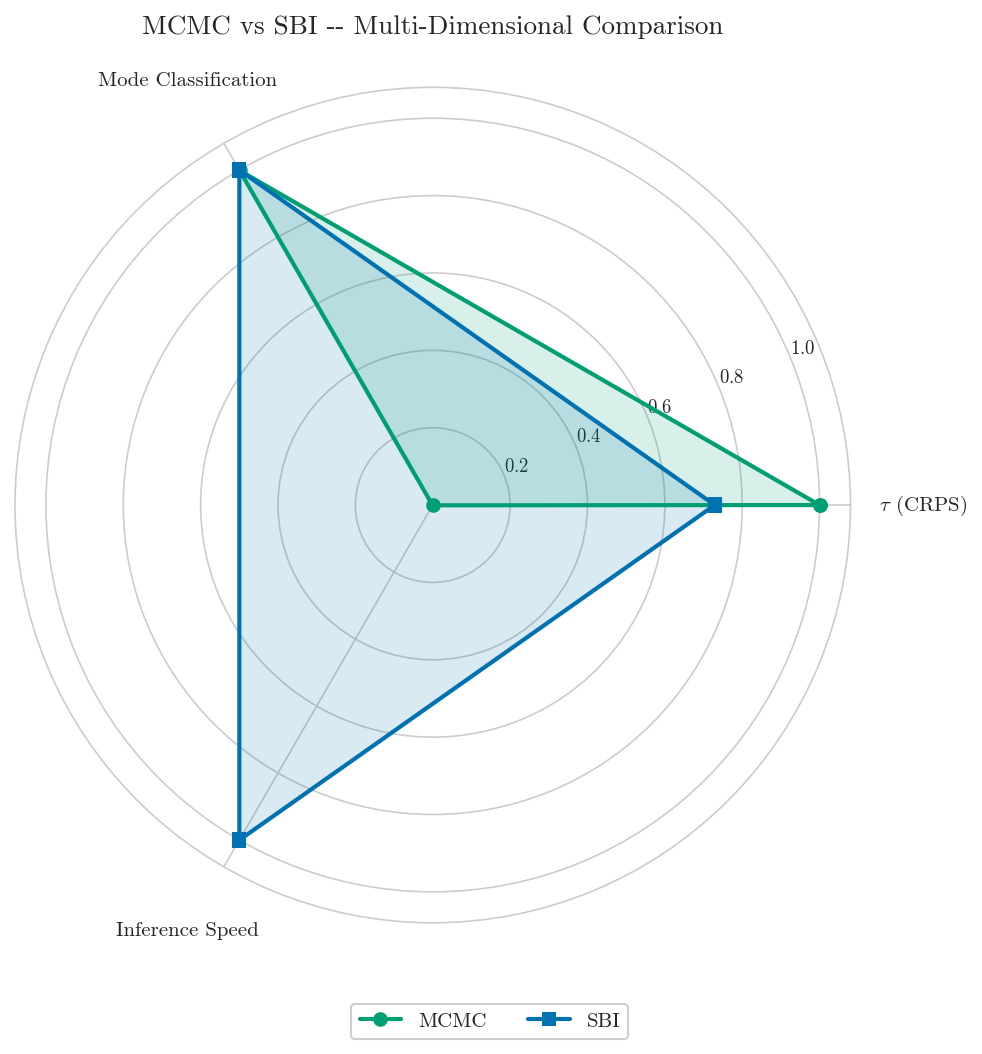

In [9]:
from math import pi

active = [s for s in SCENARIO_NAMES if 'no_failure' not in s]

avg_mcmc_crps = np.mean([mcmc_crps_tau[s] for s in active])
avg_sbi_crps = np.mean([sbi_crps_tau[s] for s in active])
avg_mcmc_acc = np.mean([mcmc_classification_acc[s] for s in active])
avg_sbi_acc = np.mean([sbi_classification_acc[s] for s in active])
avg_mcmc_time = np.mean([mcmc_time_per_obs[s] for s in active])
avg_sbi_time = np.mean([sbi_time_per_obs[s] for s in active])

# Lower CRPS is better: the better method scores 1.0 on this axis.
best_crps = min(avg_mcmc_crps, avg_sbi_crps)
mcmc_tau_score = best_crps / avg_mcmc_crps if avg_mcmc_crps > 0 else 0.0
sbi_tau_score = best_crps / avg_sbi_crps if avg_sbi_crps > 0 else 0.0

# Shorter wall time is better: the faster method scores 1.0.
min_time = min(avg_mcmc_time, avg_sbi_time)
mcmc_speed_score = min_time / avg_mcmc_time if avg_mcmc_time > 0 else 0.0
sbi_speed_score = min_time / avg_sbi_time if avg_sbi_time > 0 else 0.0

categories = [r'$\tau$ (CRPS)', 'Mode Classification', 'Inference Speed']
N_cat = len(categories)

mcmc_vals = [mcmc_tau_score, avg_mcmc_acc, mcmc_speed_score]
sbi_vals = [sbi_tau_score, avg_sbi_acc, sbi_speed_score]

print('Radar chart (each axis: 1.0 = best of the two methods on that metric):')
for cat, mv, sv in zip(categories, mcmc_vals, sbi_vals):
    print(f'  {cat}: MCMC={mv:.3f}, SBI={sv:.3f}')

angles = [n / float(N_cat) * 2 * pi for n in range(N_cat)]
angles += angles[:1]

mcmc_vals += mcmc_vals[:1]
sbi_vals += sbi_vals[:1]

fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw=dict(polar=True))
ax.plot(angles, mcmc_vals, 'o-', linewidth=2, label='MCMC', color=MCMC_COLOR)
ax.fill(angles, mcmc_vals, alpha=0.15, color=MCMC_COLOR)
ax.plot(angles, sbi_vals, 's-', linewidth=2, label='SBI', color=SBI_COLOR)
ax.fill(angles, sbi_vals, alpha=0.15, color=SBI_COLOR)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.tick_params(axis='x', pad=28)
ax.set_ylim(0, 1.08)
ax.set_title('MCMC vs SBI -- Multi-Dimensional Comparison', fontsize=13, pad=26)
ax.grid(True)

handles, leg_labels = ax.get_legend_handles_labels()
fig.legend(handles, leg_labels, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, 0.02), frameon=True, framealpha=0.95)

plt.tight_layout(rect=[0.03, 0.10, 0.97, 0.96])
save_fig(fig, figures_dir / 'radar_comparison')
plt.show()

## Summary Table

In [10]:
rows = []
for i, s in enumerate(SCENARIO_NAMES):
    speedup = mcmc_time_per_obs[s] / max(sbi_time_per_obs[s], 1e-6)
    rows.append({
        "Scenario": SCENARIO_LABELS_SHORT[i],
        "MCMC (s/obs)": f"{mcmc_time_per_obs[s]:.1f}",
        "SBI (s/obs)": f"{sbi_time_per_obs[s]:.4f}",
        "Speedup (×)": f"{speedup:.0f}",
        "MCMC Mode Acc.": f"{mcmc_classification_acc[s]*100:.0f}%",
        "SBI Mode Acc.": f"{sbi_classification_acc[s]*100:.0f}%",
    })

df = pd.DataFrame(rows)
print("Resource Comparison Summary:")
df

Resource Comparison Summary:


,Scenario,MCMC (s/obs),SBI (s/obs),Speedup (×),MCMC Mode Acc.,SBI Mode Acc.
0,Normal Op.,171.9,0.1161,1481,100%,100%
1,Batch SD,167.1,0.1186,1409,100%,100%
2,Boiler FW,146.1,0.1202,1215,100%,100%
3,Mild Leak,144.9,0.1249,1160,100%,100%
4,Severe Leak,139.1,0.1184,1175,100%,100%
5,No Failure,37.0,0.1286,288,98%,97%
